# Applied Machine Learning Workshop: Customer Support Ticket Classification

In this workshop, we will build a practical machine learning baseline for routing customer support tickets.

The model will read a ticket's subject and body, then predict the most likely support queue. This is a common first-pass ML use case: the model does not replace a support team, but it can help with triage, routing, and prioritization.

Each major code cell prints progress messages so the notebook does not appear idle during longer work. The training step also reports elapsed time.

## 1. Setup

We start by importing the libraries used throughout the notebook.

- `pandas` helps us load and inspect tabular data.
- `scikit-learn` provides the machine learning workflow.
- `matplotlib` gives us a lightweight way to visualize class balance and evaluation results.

This notebook uses scikit-learn's CPU-based implementations. It is **not using the GPU**. That is intentional for this workshop because the dataset is small enough for a laptop CPU, the model is explainable, and the environment stays simpler. GPU acceleration usually becomes relevant for larger deep learning workflows, especially neural networks and computer vision models.

You will see `RANDOM_STATE = 42` in several places. The exact number is not special. We use a fixed number as a seed so random operations, like splitting rows into training and test sets, are repeatable. If everyone uses the same seed, everyone should get the same split and very similar results.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# These display options make wide text fields and result tables easier to read.
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 40)

# A random state is a seed for repeatable pseudo-random behavior.
# The value 42 is a common convention, but any fixed integer would work.
# If we remove this, the train/test split can change every time we run the notebook.
RANDOM_STATE = 42

# This workflow uses scikit-learn estimators, which run on the CPU.
# No GPU-specific library is imported here, and LogisticRegression has no GPU switch.
print("Step 1 complete: imports loaded, display options set, and RANDOM_STATE fixed at 42.", flush=True)
print("Runtime note: this workshop pipeline uses CPU-based scikit-learn, not the GPU.", flush=True)

Step 1 complete: imports loaded, display options set, and RANDOM_STATE fixed at 42.
Runtime note: this workshop pipeline uses CPU-based scikit-learn, not the GPU.


## 2. Load the Dataset

The dataset has been copied into this project under `data/support_tickets.csv` so the notebook can run without depending on a file in Downloads.

The path logic below works whether Jupyter starts in the project root or inside the `notebooks` folder. Loading the CSV is usually quick, but the cell prints before and after reading so we can tell what is happening.

In [2]:
print("Step 2 started: locating and loading data/support_tickets.csv...", flush=True)

project_root = Path.cwd()
if not (project_root / "data" / "support_tickets.csv").exists():
    # If Jupyter starts inside the notebooks folder, the data folder is one level up.
    project_root = project_root.parent

data_path = project_root / "data" / "support_tickets.csv"

start = perf_counter()
tickets = pd.read_csv(data_path)
elapsed = perf_counter() - start

print(f"Step 2 complete: loaded {tickets.shape[0]:,} rows and {tickets.shape[1]:,} columns in {elapsed:.2f} seconds.", flush=True)
display(tickets.head())

Step 2 started: locating and loading data/support_tickets.csv...
Step 2 complete: loaded 28,587 rows and 16 columns in 0.19 seconds.


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infr...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie de...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which curren...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical te...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabil...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility detai...",Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and paym...",We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of the month and conclu...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the s...","Thank you for your inquiry. Our product supports integration with major CRM, email marketing, and analytics platforms through APIs and c...",Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


## 3. Inspect the Data

Before training anything, we need to understand what the dataset contains.

Missing values mean a cell is blank or unavailable. For example, a missing `subject` would mean the ticket does not have a subject line. Missing values matter because many ML algorithms expect complete inputs, and because missingness itself may reveal data collection problems.

The number of unique values is also important. For a prediction target, unique values tell us how many classes the model must learn. For text fields, unique counts help us understand whether most rows are distinct or repetitive. For categorical fields like `queue`, unique counts show the size of the routing problem.

This is one of the most important habits in applied machine learning: inspect the data before choosing the model.

In [3]:
print("Step 3 started: inspecting columns, missing values, and unique values...", flush=True)

# info() shows column names, non-null counts, and data types.
# Non-null means the value is present. If non-null is less than the row count, that column has missing values.
tickets.info()

# Missing values tell us which fields may need cleaning before modeling.
# Unique values tell us whether columns behave like IDs, categories, labels, or free text.
summary = pd.DataFrame(
    {
        "missing_values": tickets.isna().sum(),
        "unique_values": tickets.nunique(dropna=True),
    }
)

print("Step 3 complete: data profile generated.", flush=True)
display(summary)

Step 3 started: inspecting columns, missing values, and unique values...
<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB
Step 3 complete: data profile generated.


,missing_values,unique_values
subject,3838,24749
body,0,28587
answer,7,28580
type,0,4
queue,0,10
priority,0,3
language,0,2
version,0,3
tag_1,0,116
tag_2,13,256


In [4]:
print("Step 3 continued: checking class balance for key categorical columns...", flush=True)

# Class balance affects model behavior.
# If one queue appears much more often than another, a model can look accurate while doing poorly on smaller classes.
print("Language counts")
display(tickets["language"].value_counts())

print("Support queue counts")
display(tickets["queue"].value_counts())

print("Priority counts")
display(tickets["priority"].value_counts())

print("Ticket type counts")
display(tickets["type"].value_counts())

print("Step 3 complete: class distributions reviewed.", flush=True)

Step 3 continued: checking class balance for key categorical columns...
Language counts


language
en    16338
de    12249
Name: count, dtype: int64

Support queue counts


queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

Priority counts


priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

Ticket type counts


type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

Step 3 complete: class distributions reviewed.


## 4. Choose a Prediction Target

For this workshop, we will predict the `queue` column.

That means the model is learning a routing task: given the text of a ticket, which team or queue should handle it?

We will use English-language rows only. The original dataset also contains German tickets, which is useful for a later discussion about multilingual ML systems, but using one language keeps this 3-hour workshop focused.

In [5]:
print("Step 4 started: filtering to English-language rows and choosing queue as the target...", flush=True)

# We are filtering to English rows because the vectorizer below uses English stop words.
# Mixing languages is possible, but it changes the modeling problem and the evaluation discussion.
english_tickets = tickets[tickets["language"].str.lower() == "en"].copy()

print(f"Step 4 complete: kept {len(english_tickets):,} English-language tickets.", flush=True)
display(english_tickets[["subject", "body", "queue", "priority", "type"]].head())

Step 4 started: filtering to English-language rows and choosing queue as the target...
Step 4 complete: kept 16,338 English-language tickets.


,subject,body,queue,priority,type
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which curren...",Technical Support,high,Incident
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabil...",Returns and Exchanges,medium,Request
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and paym...",Billing and Payments,low,Request
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the s...",Sales and Pre-Sales,medium,Problem
5,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the features of one of your pro...",Technical Support,high,Request


## 5. Prepare the Text and Labels

Machine learning models need features and labels.

- The feature will be the ticket text, created from `subject` plus `body`.
- The label will be `queue`, the support queue we want the model to predict.

We also remove rows where the combined text is blank or the target label is missing.

It is tempting to give the model every column in the dataset, but that can create leakage. Leakage happens when training data includes information that would not be available at prediction time. For example, using the final support `answer` could make the model look better in the notebook while failing in real ticket intake, because a new ticket does not have an answer yet.

In [6]:
print("Step 5 started: preparing model features and labels...", flush=True)

model_data = english_tickets.copy()

# Text models cannot use missing text directly, so we replace missing subject/body values with empty strings.
# This keeps the row usable if at least one text field is present.
model_data["subject"] = model_data["subject"].fillna("")
model_data["body"] = model_data["body"].fillna("")

# Combine subject and body because both are available when a new ticket arrives.
# We intentionally do not use the answer column because that would leak future information.
model_data["ticket_text"] = (model_data["subject"] + "\n\n" + model_data["body"]).str.strip()

# Keep rows where we have input text and a queue label to learn from.
model_data = model_data[(model_data["ticket_text"] != "") & model_data["queue"].notna()].copy()

X = model_data["ticket_text"]
y = model_data["queue"]

print(f"Step 5 complete: prepared {len(model_data):,} usable rows with {y.nunique()} queue classes.", flush=True)
display(model_data[["ticket_text", "queue"]].head())

Step 5 started: preparing model features and labels...
Step 5 complete: prepared 16,338 usable rows with 10 queue classes.


,ticket_text,queue
1,"Account Disruption\n\nDear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account managemen...",Technical Support
2,"Query About Smart Home System Integration Features\n\nDear Customer Support Team,\n\nI hope this message reaches you well. I am reaching...",Returns and Exchanges
3,"Inquiry Regarding Invoice Details\n\nDear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request cla...",Billing and Payments
4,"Question About Marketing Agency Software Compatibility\n\nDear Support Team,\n\nI hope this message reaches you well. I am reaching out ...",Sales and Pre-Sales
5,"Feature Query\n\nDear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the features o...",Technical Support


Step 5 continued: visualizing class balance for the target label...


queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

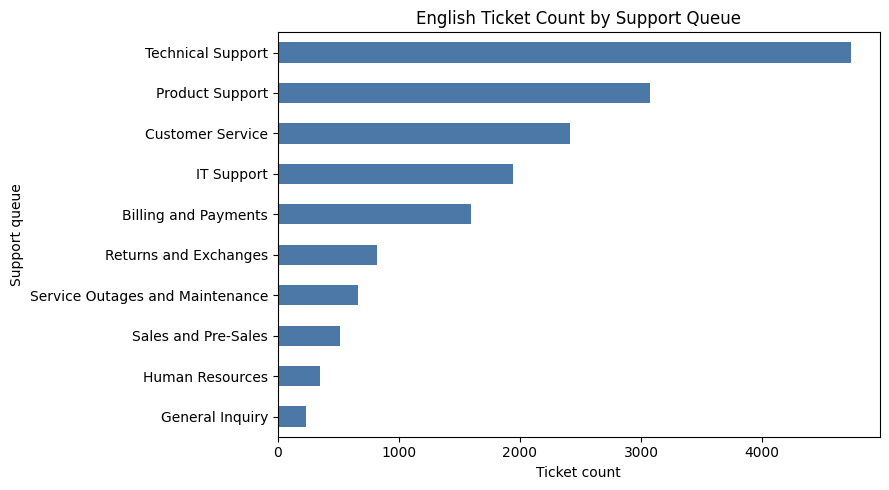

Step 5 complete: class balance chart rendered.


In [7]:
print("Step 5 continued: visualizing class balance for the target label...", flush=True)

queue_counts = y.value_counts()
display(queue_counts)

ax = queue_counts.sort_values().plot(kind="barh", figsize=(9, 5), color="#4C78A8")
ax.set_title("English Ticket Count by Support Queue")
ax.set_xlabel("Ticket count")
ax.set_ylabel("Support queue")
plt.tight_layout()
plt.show()

print("Step 5 complete: class balance chart rendered.", flush=True)

Class balance matters. If one support queue appears far more often than another, the model may learn to favor the larger classes.

We will use a weighted Logistic Regression model later so smaller classes still influence training. That does not magically solve class imbalance, but it is a reasonable baseline choice.

## 6. Split into Training and Test Sets

We train the model on one portion of the data and evaluate it on a separate holdout set.

Using all data for training is dangerous because it only tells us how well the model fits examples it has already seen. That is like grading a student with the answer key open. The model can appear strong while failing on new tickets.

The test set gives us a more honest estimate of how the model behaves on unseen data. We also use `stratify=y` so the train and test sets keep roughly the same queue proportions as the full dataset.

In [8]:
print("Step 6 started: splitting data into training and test sets...", flush=True)

# test_size=0.25 means 25% of rows are held back for evaluation.
# random_state makes the split repeatable.
# stratify=y keeps the class mix similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Step 6 complete: {len(X_train):,} training rows and {len(X_test):,} test rows.", flush=True)

Step 6 started: splitting data into training and test sets...
Step 6 complete: 12,253 training rows and 4,085 test rows.


## 7. Build a Baseline Model

This baseline uses two steps.

First, `TfidfVectorizer` converts text into numeric features. TF-IDF stands for term frequency-inverse document frequency.

- Term frequency asks: how often does a word appear in this ticket?
- Inverse document frequency asks: how rare is that word across all tickets?
- A word that appears often in one ticket but not in every ticket can be more informative.
- A word that appears everywhere, like a common filler word, is usually less useful.

That is what we mean by word importance here. It is not understanding language like a human. It is scoring words and short phrases based on how useful they may be for separating classes.

Second, `LogisticRegression` learns a classifier. Despite the name, Logistic Regression can be used for classification. It learns weights for the text features. If certain words or phrases are strongly associated with `Billing and Payments`, those features push the prediction toward that queue. If other words are associated with `Service Outages and Maintenance`, they push the prediction in that direction.

The model learns by comparing its predictions on the training data to the known labels, then adjusting feature weights to reduce mistakes. The result is a fast, explainable baseline that is often a good first model for text classification.

In [9]:
print("Step 7 started: building the TF-IDF plus Logistic Regression pipeline...", flush=True)

model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                # English stop words removes common words such as "the" and "and".
                # This is one reason we filtered to English rows earlier.
                stop_words="english",
                # Limit vocabulary size so the notebook stays fast and readable.
                max_features=10000,
                # Include individual words and two-word phrases.
                # Phrases like "credit card" can be more meaningful than either word alone.
                ngram_range=(1, 2),
                # Ignore words/phrases that appear in only one row.
                # Very rare terms can add noise instead of reusable signal.
                min_df=2,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                # More iterations gives the optimizer enough room to converge.
                max_iter=2000,
                # Balanced class weights reduce the tendency to ignore smaller queues.
                class_weight="balanced",
                # Keeps any internal randomized behavior repeatable.
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print("Step 7 complete: model pipeline created. No training has happened yet.", flush=True)
model

Step 7 started: building the TF-IDF plus Logistic Regression pipeline...
Step 7 complete: model pipeline created. No training has happened yet.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 8. Train the Model

Training is where the pipeline learns from labeled examples.

During `fit`, the vectorizer scans the training text and builds a vocabulary of useful words and phrases. Then it transforms every training ticket into numbers. The classifier then learns which numeric patterns point toward each support queue.

The test set is not used during training. That separation matters because we want the final evaluation to represent new tickets, not memorized rows.

This is usually the slowest cell in the notebook, so it prints a start message immediately and a completion message with elapsed time when training finishes.

In [10]:
print("Step 8 started: training the model. This may take a little while...", flush=True)

start = perf_counter()
model.fit(X_train, y_train)
elapsed = perf_counter() - start

print(f"Step 8 complete: model training finished in {elapsed:.2f} seconds.", flush=True)

Step 8 started: training the model. This may take a little while...
Step 8 complete: model training finished in 1.47 seconds.


## 9. Evaluate the Model

Accuracy is useful, but it is not enough by itself.

The classification report includes several metrics:

- `precision`: Of the tickets predicted as a queue, how many were actually that queue? Low precision means many false alarms for that queue.
- `recall`: Of the tickets that truly belonged to a queue, how many did the model find? Low recall means many missed tickets for that queue.
- `f1-score`: A combined score that balances precision and recall. It is useful when you want one number per class, especially with uneven classes.
- `support`: The number of test examples for that class. Small support means the metric is based on fewer examples and should be interpreted more carefully.

In a support workflow, precision and recall have business implications. For example, low recall for billing means billing tickets may get routed elsewhere. Low precision for billing means other teams' tickets may get incorrectly routed into billing.

In [11]:
print("Step 9 started: generating predictions and evaluation metrics...", flush=True)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Step 9 progress: accuracy calculated at {accuracy:.3f}.", flush=True)

report = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Step 9 complete: classification report ready.", flush=True)
display(report_df)

Step 9 started: generating predictions and evaluation metrics...
Step 9 progress: accuracy calculated at 0.493.
Step 9 complete: classification report ready.


,precision,recall,f1-score,support
Billing and Payments,0.785340,0.751880,0.768246,399.000000
Customer Service,0.423214,0.393035,0.407567,603.000000
General Inquiry,0.345455,0.644068,0.449704,59.000000
Human Resources,0.401408,0.655172,0.497817,87.000000
IT Support,0.372681,0.454733,0.409639,486.000000
Product Support,0.498387,0.402344,0.445245,768.000000
Returns and Exchanges,0.348432,0.487805,0.406504,205.000000
Sales and Pre-Sales,0.310606,0.640625,0.418367,128.000000
Service Outages and Maintenance,0.533058,0.777108,0.632353,166.000000
Technical Support,0.611299,0.456926,0.522958,1184.000000


In [ ]:
print("Step 9 continued: building the confusion matrix...", flush=True)

labels = list(model.classes_)
matrix = confusion_matrix(y_test, predictions, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, cmap="Blues")

ax.set_title("Confusion Matrix: Actual Queue vs Predicted Queue")
ax.set_xlabel("Predicted queue")
ax.set_ylabel("Actual queue")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

confusion_df = pd.DataFrame(matrix, index=labels, columns=labels)
display(confusion_df)

print("Step 9 complete: confusion matrix rendered.", flush=True)

The confusion matrix shows where the model sends tickets.

Rows are actual queues. Columns are predicted queues. Strong numbers on the diagonal are correct predictions. Large off-diagonal numbers show common routing mistakes worth discussing with business stakeholders.

## 10. Inspect Mistakes

Aggregate metrics tell us how the model performs overall. Looking at individual mistakes tells us why.

In a real workflow, this is where you often discover unclear labels, overlapping categories, missing context, or business rules that the model cannot infer from text alone.

In [ ]:
print("Step 10 started: collecting misclassified tickets for inspection...", flush=True)

test_results = pd.DataFrame(
    {
        "ticket_text": X_test,
        "actual_queue": y_test,
        "predicted_queue": predictions,
    }
)

# Predictive probabilities let us approximate confidence for this classifier.
# High-confidence mistakes are especially important because the model is strongly wrong.
probabilities = model.predict_proba(X_test)
test_results["prediction_confidence"] = probabilities.max(axis=1)

mistakes = test_results[test_results["actual_queue"] != test_results["predicted_queue"]].copy()
mistakes["text_preview"] = mistakes["ticket_text"].str.replace("\n", " ", regex=False).str.slice(0, 300)

print(f"Step 10 complete: found {len(mistakes):,} misclassified rows.", flush=True)
display(
    mistakes.sort_values("prediction_confidence", ascending=False)[
        ["actual_queue", "predicted_queue", "prediction_confidence", "text_preview"]
    ].head(10)
)

High-confidence mistakes are especially useful to inspect. They can show where the model is strongly wrong, which is more concerning than a low-confidence uncertain prediction.

The implication is practical: if a system routes tickets automatically, high-confidence errors can create operational problems. A safer early use is to suggest a queue and let a human confirm it.

## 11. Try a Few Custom Examples

Now we can test a few short examples that resemble incoming tickets.

These examples are not a substitute for formal evaluation, but they make the model behavior easier to discuss.

In [ ]:
print("Step 11 started: trying custom support-ticket examples...", flush=True)

custom_examples = pd.Series(
    [
        "I was charged twice for my monthly subscription and need help with my invoice.",
        "The application is unavailable for all users and our team cannot access the portal.",
        "Can you explain whether this product integrates with our CRM and analytics tools?",
        "I need to return a device that arrived damaged and exchange it for a replacement.",
    ]
)

custom_predictions = model.predict(custom_examples)
custom_probabilities = model.predict_proba(custom_examples)
custom_confidence = custom_probabilities.max(axis=1)

custom_results = pd.DataFrame(
    {
        "ticket_text": custom_examples,
        "predicted_queue": custom_predictions,
        "confidence": custom_confidence,
    }
)

print("Step 11 complete: custom examples scored.", flush=True)
display(custom_results)

## 12. Discuss Real-World Use

A model like this is best treated as an assistant, not an autonomous decision-maker.

Useful support workflows could include:

- suggesting a queue during ticket intake
- prioritizing tickets for human review
- flagging uncertain tickets for manual routing
- helping managers understand ticket mix over time

Before using this in production, an organization would need to address:

- privacy and data governance
- human review for customer-impacting actions
- monitoring for changing support patterns
- retraining with fresh labeled examples
- clear handling of low-confidence predictions
- review of model errors by business stakeholders

## 13. Optional Extension: How This Differs From Image/Logo ML

This workshop focused on text classification. A logo normalization workflow would look different.

Text classification uses words and phrases as features. Image workflows use pixels, edges, colors, shapes, and visual patterns.

Logo normalization may involve background removal, resizing, color normalization, segmentation, vectorization, quality checks, and print-readiness rules. That makes it a good future computer vision workshop, but too much to combine deeply with this 3-hour text ML session.

## Closing Takeaways

- Machine learning is a workflow, not a single function call.
- Data inspection and preparation shape the quality of the model.
- A simple baseline is valuable because it gives you something measurable.
- Accuracy alone can hide important failures.
- Real-world use requires monitoring, governance, retraining, and human oversight.